# Stage-Wise Consensus miRNA Signatures (Normal vs. Stage I–IV): Traditional, Deep Learning, and Clustering

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

## Validate inputs before stage-wise consensus

In [2]:
# root where team files live
base = Path("TeamsExports")  

# Expected sets
stages = ["Stage_I", "Stage_II", "Stage_III", "Stage_IV"]
kvals  = [5, 10, 15]

trad = ["SFS", "VT", "Chi2", "LASSO"]
dl   = ["FNN", "DAE", "CNN1D", "LSTMSeq"]
clus = ["KM", "SC", "GMM", "HC"]

# Build expected file list
expected = []

# Traditional & Deep Learning: per k and stage
for approach, methods in [("Traditional", trad), ("DeepLearning", dl)]:
    for m in methods:
        for s in stages:
            for k in kvals:
                expected.append(base / approach / m / f"{m}_top{k}_{s}.csv")

# Clustering: per stage (selected cluster)
for m in clus:
    for s in stages:
        expected.append(base / "Clustering" / m / f"{m}_selected_{s}.csv")

expected_set = set(expected)

# Actual CSVs under TeamsExports
actual_set = {p for p in base.rglob("*.csv") if p.is_file()}

missing = [p for p in expected if p not in actual_set]
extra   = sorted(p for p in actual_set if p not in expected_set)

print(f"Expected files: {len(expected_set)}")
print(f"Found:          {len(actual_set) - len(extra)}")
print(f"Missing:        {len(missing)}")
print(f"Unexpected:     {len(extra)}\n")

if missing:
    print("Missing files:")
    for p in missing:
        print("  -", p.as_posix())
    print("")

if extra:
    print("Unexpected files (name/path mismatch?):")
    for p in extra:
        print("  -", p.as_posix())
    print("")

# Content validation for files we have
problems = []
for p in sorted(expected_set & actual_set):
    try:
        # Read just the first column fast
        df = pd.read_csv(p, header=0)
        # Header check
        if df.shape[1] < 1 or df.columns[0] != "miRNA":
            problems.append((p, "first column header must be exactly 'miRNA'"))
            continue
        # Empty check
        if df.shape[0] == 0:
            problems.append((p, "file has zero rows"))
            continue
        # NaN / blank lines
        col = df.iloc[:, 0].astype(str).str.strip()
        if col.eq("").any():
            problems.append((p, "blank miRNA entries found"))
        # Duplicates
        dups = col[col.duplicated()].unique().tolist()
        if dups:
            problems.append((p, f"duplicate miRNAs: {dups[:5]}{'...' if len(dups)>5 else ''}"))
    except Exception as e:
        problems.append((p, f"read error: {e!s}"))

if problems:
    print("Content issues detected:")
    for p, msg in problems:
        print(f"  - {p.as_posix()}: {msg}")
    print("\nPlease fix the issues above, then re-run this validator.")
else:
    print("All present files passed header/emptiness/duplicate checks.")

Expected files: 112
Found:          112
Missing:        0
Unexpected:     0

All present files passed header/emptiness/duplicate checks.


## Stage-wise consensus

In [3]:
# Display name and file slug for each method
Traditional = [("SFS", "SFS"), ("VT", "VT"), ("Chi2", "Chi2"), ("LASSO", "LASSO")]
DeepLearning = [("FNN", "FNN"), ("DAE", "DAE"), ("1D-CNN", "CNN1D"), ("LSTM-Seq", "LSTMSeq")]
Clustering = [("KM", "KM"), ("SC", "SC"), ("GMM", "GMM"), ("HC", "HC")]

# Stages: (display, slug used in filenames)
stages = [("Stage I", "Stage_I"),
          ("Stage II", "Stage_II"),
          ("Stage III", "Stage_III"),
          ("Stage IV", "Stage_IV")]

k_values = [5, 10, 15]

# Root folders
base = Path("TeamsExports")     
out  = Path("stagewise_consensus")       
out.mkdir(exist_ok=True)

# Helpers
def load_list(fp: Path) -> pd.Series:
    s = pd.read_csv(fp, header=0).iloc[:, 0].astype(str)
    return s.str.strip().str.lower().dropna().drop_duplicates().rename("miRNA")

def consensus_from(lists: dict):
    rows = [{"miRNA": m, "method": name} for name, ser in lists.items() for m in ser]
    if not rows:
        return (pd.DataFrame(columns=["miRNA","freq","picked_by"]),
                pd.Index([]), pd.Index([]), pd.Index([]))
    df = pd.DataFrame(rows)
    freq = (df.groupby("miRNA")["method"]
              .agg(lambda x: sorted(set(x)))
              .reset_index())
    freq["freq"] = freq["method"].apply(len)
    freq["picked_by"] = freq["method"].apply(lambda xs: ",".join(xs))
    freq = freq.drop(columns=["method"]).sort_values(["freq","miRNA"], ascending=[False, True])
    inters = freq.loc[freq["freq"] == 4, "miRNA"]
    maj    = freq.loc[freq["freq"] >= 2, "miRNA"]
    uni    = freq["miRNA"]
    return freq, inters, maj, uni

def save_series(path: Path, idx: pd.Index):
    pd.Series(idx, name="miRNA").to_csv(path, index=False)

# Run consensus: Traditional & Deep Learning (per k)
summary_rows = []

for approach_name, methods in [("Traditional", Traditional), ("DeepLearning", DeepLearning)]:
    for stage_disp, stage_slug in stages:
        for k in k_values:
            lists = {}
            for disp, slug in methods:
                fp = base / approach_name / slug / f"{slug}_top{k}_{stage_slug}.csv"
                if fp.exists():
                    lists[disp] = load_list(fp)
            # Build consensus for whatever files exist for this (approach, stage, k)
            freq, inters, maj, uni = consensus_from(lists)

            stem = f"Consensus_{approach_name}_top{k}_{stage_slug}"
            freq.to_csv(out / f"{stem}_freq_table.csv", index=False)
            save_series(out / f"{stem}_intersection.csv", inters)
            save_series(out / f"{stem}_majority.csv",     maj)
            save_series(out / f"{stem}_union.csv",        uni)

            summary_rows.append({
                "Approach": approach_name,
                "Stage": stage_disp,
                "k": k,
                "n_methods_found": len(lists),
                "n_intersection": len(inters),
                "n_majority": len(maj),
                "n_union": len(uni)
            })

# Run consensus: Clustering (no k)
approach_name = "Clustering"
for stage_disp, stage_slug in stages:
    lists = {}
    for disp, slug in Clustering:
        fp = base / approach_name / slug / f"{slug}_selected_{stage_slug}.csv"
        if fp.exists():
            lists[disp] = load_list(fp)
    freq, inters, maj, uni = consensus_from(lists)

    stem = f"Consensus_Clustering_{stage_slug}"
    freq.to_csv(out / f"{stem}_freq_table.csv", index=False)
    save_series(out / f"{stem}_intersection.csv", inters)
    save_series(out / f"{stem}_majority.csv",     maj)
    save_series(out / f"{stem}_union.csv",        uni)

    summary_rows.append({
        "Approach": approach_name,
        "Stage": stage_disp,
        "k": "",
        "n_methods_found": len(lists),
        "n_intersection": len(inters),
        "n_majority": len(maj),
        "n_union": len(uni)
    })

# Overall summary
summary_df = pd.DataFrame(summary_rows, columns=[
    "Approach", "Stage", "k", "n_methods_found", "n_intersection", "n_majority", "n_union"
])
summary_df.to_csv(out / "Consensus_Summary_All_Stages.csv", index=False)

print(summary_df.to_string(index=False))

    Approach     Stage  k  n_methods_found  n_intersection  n_majority  n_union
 Traditional   Stage I  5                4               0           4       16
 Traditional   Stage I 10                4               0           6       34
 Traditional   Stage I 15                4               0           8       51
 Traditional  Stage II  5                4               0           3       16
 Traditional  Stage II 10                4               0           6       33
 Traditional  Stage II 15                4               0           9       49
 Traditional Stage III  5                4               0           2       18
 Traditional Stage III 10                4               0           7       33
 Traditional Stage III 15                4               0           9       50
 Traditional  Stage IV  5                4               0           3       17
 Traditional  Stage IV 10                4               0           6       34
 Traditional  Stage IV 15               

## Consensus Heatmaps

In [4]:
# Build consensus_df for plotting (from summary_df)
consensus_df = summary_df.rename(columns={"Approach": "Family"}).copy()

# Robust k: keep numbers as int; map blanks/other to "—" (Clustering has "")
def _to_k(x):
    if pd.isna(x): 
        return "—"
    s = str(x).strip()
    if s in {"", "—", "-", "None", "none", "nan"}:
        return "—"
    try:
        return int(float(s))  # handles "5" or "5.0"
    except Exception:
        return "—"

consensus_df["k"] = consensus_df["k"].apply(_to_k)

# Ensure counts are numeric
consensus_df["n_majority"] = pd.to_numeric(consensus_df["n_majority"], errors="coerce")

# quick sanity check
assert {"Family","Stage","k","n_majority"} <= set(consensus_df.columns)
print("consensus_df ready. Rows:", len(consensus_df))

consensus_df ready. Rows: 28


In [5]:
# Single-Family Consensus Heatmap (robust to k="—")
def plot_consensus_heatmap_single(df, family, value_col="n_majority", save_path=None):
    stages_order = ["Stage I","Stage II","Stage III","Stage IV"]

    sub = df[df["Family"] == family].copy()
    if sub.empty:
        raise ValueError(f"No rows found for Family='{family}'")

    # Robust k normalizer: keep numeric as int; map everything else to "—"
    def _fix_k(x):
        if pd.isna(x):
            return "—"
        s = str(x).strip()
        if s in {"", "—", "-", "None", "nan"}:
            return "—"
        try:
            # handle "5.0" etc.
            return int(float(s))
        except Exception:
            return "—"

    sub["k"] = sub["k"].apply(_fix_k)

    # k ordering: numeric first (sorted), then "—"
    k_vals = list(pd.unique(sub["k"]))
    k_numeric = sorted([k for k in k_vals if isinstance(k, (int, np.integer))])
    k_other   = [k for k in k_vals if not isinstance(k, (int, np.integer))]
    k_order   = k_numeric + k_other

    # Pivot (silence FutureWarning)
    mat = (sub.pivot_table(index="k", columns="Stage", values=value_col,
                           aggfunc="first", observed=False)
             .reindex(index=k_order, columns=stages_order))

    fig, ax = plt.subplots(1, 1, figsize=(4.8, 3.8))
    im = ax.imshow(mat.values, aspect="auto")  # default cmap

    ax.set_xticks(range(len(stages_order)))
    ax.set_xticklabels(stages_order)
    ax.set_yticks(range(len(k_order)))
    ax.set_yticklabels(k_order)
    ax.set_xlabel("Stage")
    ax.set_ylabel("k")
    ax.set_title(f"{family} — Majority Consensus Size", pad=8)

    # annotate integers; format thousands for big counts
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            if v is not None and not (isinstance(v, float) and np.isnan(v)):
                ax.text(j, i, f"{int(v):,}", ha="center", va="center", fontsize=9)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.06)
    cbar.ax.set_ylabel("Count", rotation=270, labelpad=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

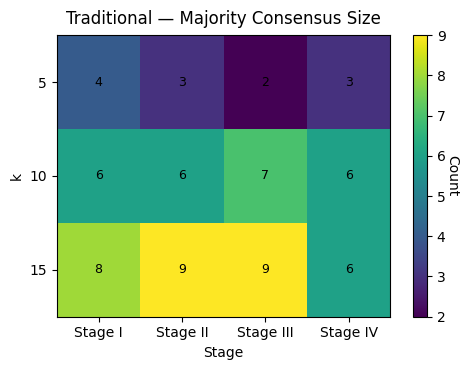

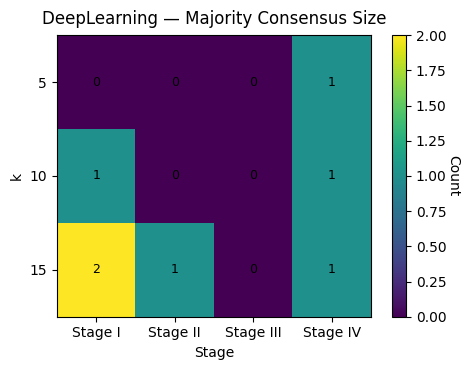

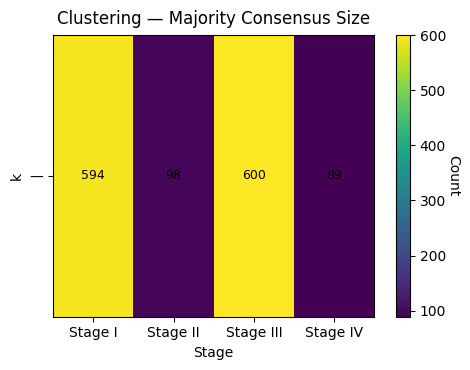

In [6]:
plot_consensus_heatmap_single(consensus_df, "Traditional")
plot_consensus_heatmap_single(consensus_df, "DeepLearning")
plot_consensus_heatmap_single(consensus_df, "Clustering")